# AG News Exploratory Data Analysis

This notebook explores the real AG News dataset before model training. The same reusable analysis is implemented in `src/eda.py`.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FIGURE_DIR, LABEL_NAMES, METRICS_DIR
from src.data_preprocessing import load_raw_data
from src.eda import run_eda

## 1. Load and inspect the dataset

AG News provides an official training split and an untouched test split.

In [2]:
raw_data = load_raw_data()
print(raw_data)
print('Train rows:', len(raw_data['train']))
print('Test rows:', len(raw_data['test']))
display(raw_data['train'].to_pandas().head())

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Train rows: 120000
Test rows: 7600


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


## 2. Run the complete EDA

This calculates class balance, missing values, duplicates, text lengths, token lengths, vocabulary statistics, and saves the report figures. It also repairs incomplete HTML artifacts such as `quot;`, `amp;`, and `#39;`. Token lengths are measured with the same DistilBERT tokenizer used during training.

In [3]:
summary, train_eda, test_eda = run_eda()
display(pd.DataFrame({
    'Statistic': list(summary.keys()),
    'Value': [str(value) for value in summary.values()]
}))

,Statistic,Value
0,train_rows,120000
1,test_rows,7600
2,number_of_classes,4
3,class_distribution,"{'World': 30000, 'Sports': 30000, 'Business': ..."
4,missing_train_texts,0
5,missing_test_texts,0
6,duplicate_train_texts,137
7,duplicate_test_texts,0
8,exact_train_test_overlap,13
9,average_words,37.68


## 3. Class distribution

A balanced class distribution means accuracy is meaningful, although macro F1 is still reported so every class receives equal importance.

,Class,Articles
0,World,30000
1,Sports,30000
2,Business,30000
3,Sci/Tech,30000


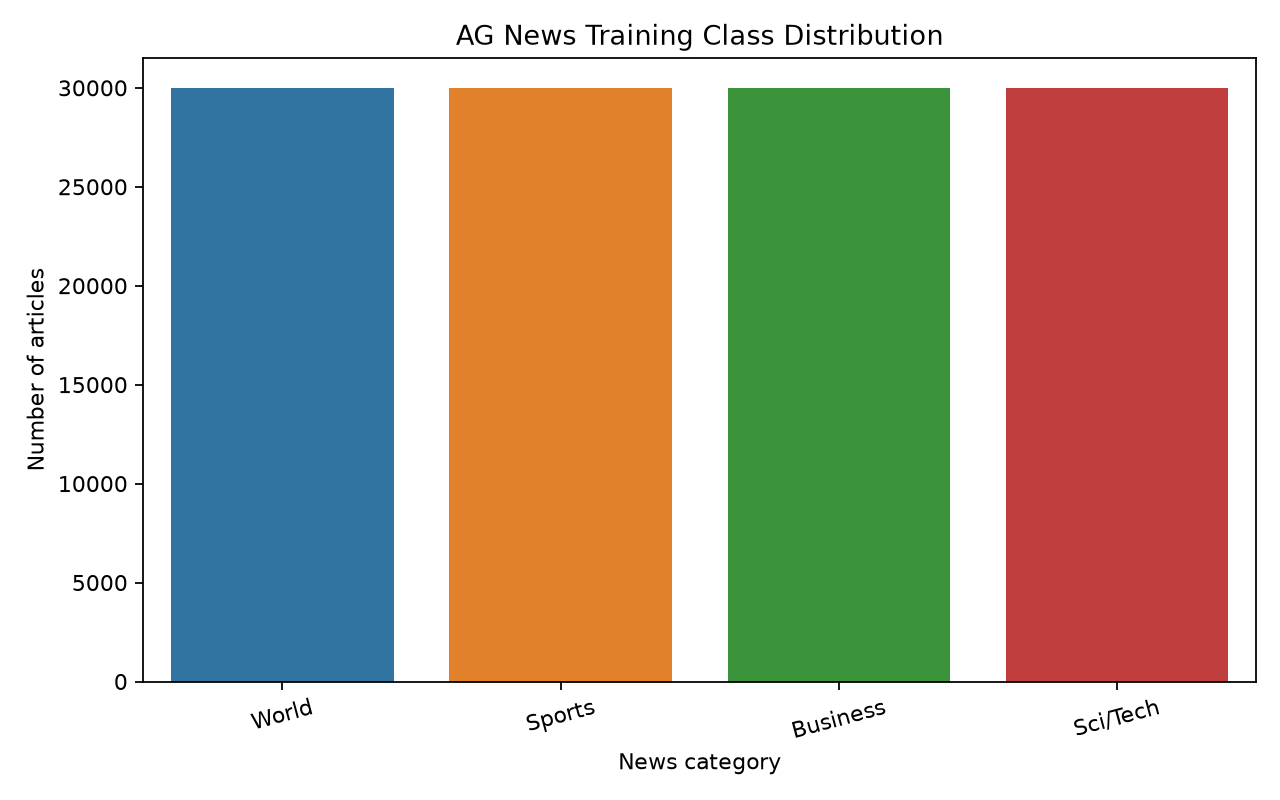

In [4]:
class_table = (train_eda['label_name'].value_counts()
               .reindex(LABEL_NAMES)
               .rename_axis('Class')
               .reset_index(name='Articles'))
display(class_table)
display(Image(filename=str(FIGURE_DIR / 'class_distribution.png')))

## 4. Text and token lengths

The word and token distributions help justify the maximum sequence length. A length of 128 should only be retained if it covers most examples according to the observed percentiles.

,word_count,character_count,token_count
count,120000.000000,120000.000000,120000.000000
mean,37.679792,233.299042,51.541467
std,10.173637,64.741949,17.467133
min,8.000000,80.000000,14.000000
50%,37.000000,229.000000,49.000000
90%,48.000000,296.000000,67.000000
95%,53.000000,336.000000,78.000000
99%,70.000000,457.000000,116.000000
max,177.000000,976.000000,327.000000


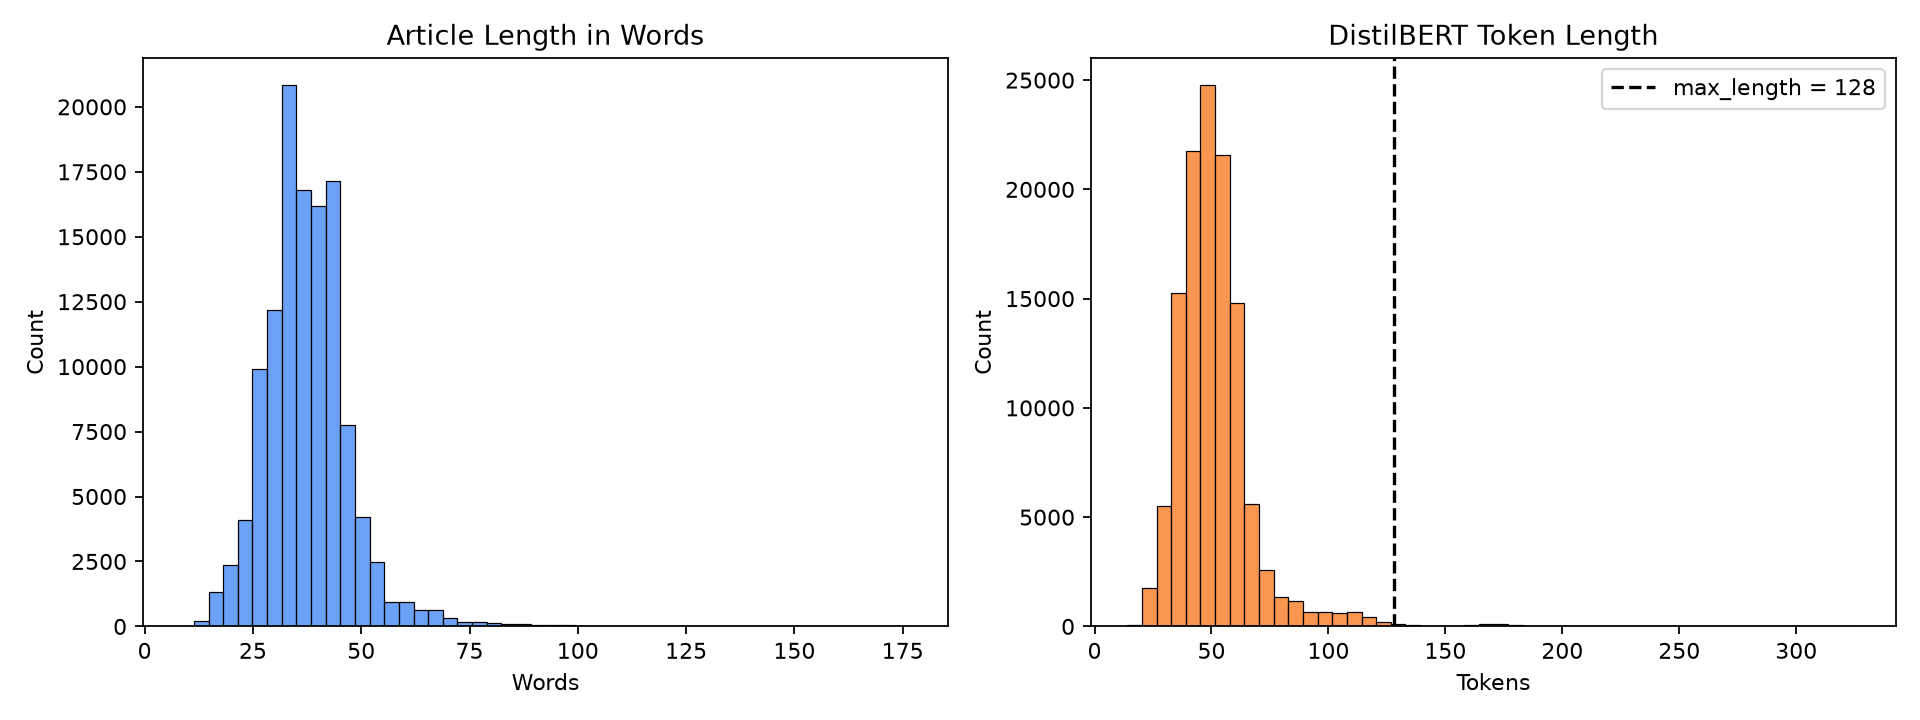

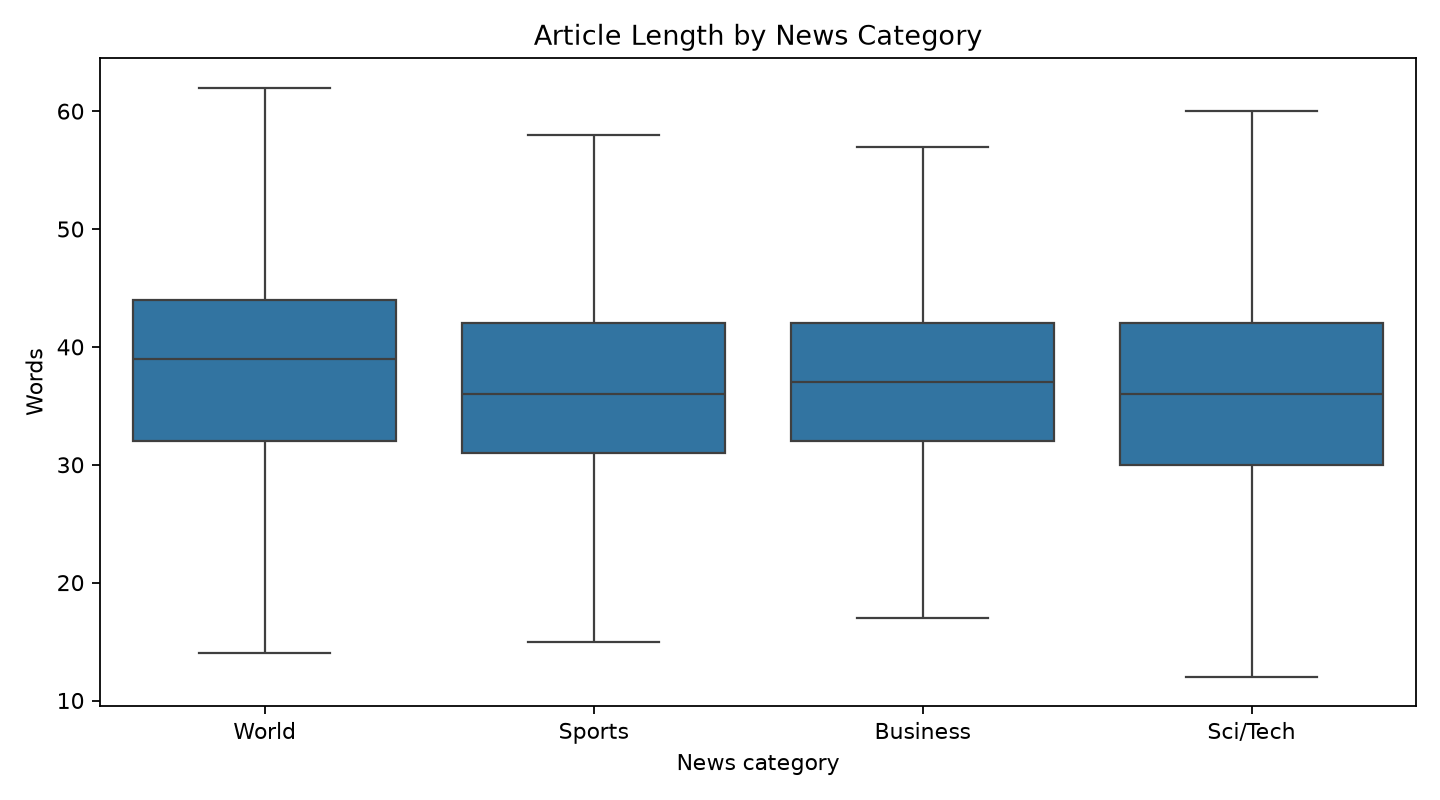

In [5]:
display(train_eda[['word_count', 'character_count', 'token_count']].describe(percentiles=[.5, .9, .95, .99]))
display(Image(filename=str(FIGURE_DIR / 'length_distributions.png')))
display(Image(filename=str(FIGURE_DIR / 'length_by_class.png')))

## 5. Vocabulary characteristics and examples

Frequent words indicate common news language. Class examples help identify overlap, such as technology companies appearing in both Business and Sci/Tech.

Approximate unique word forms: 81398


,Word,Frequency
0,new,21338
1,said,20264
2,reuters,19340
3,ap,16228
4,monday,7521
5,wednesday,7402
6,tuesday,7326
7,oil,7235
8,thursday,7217
9,friday,6723


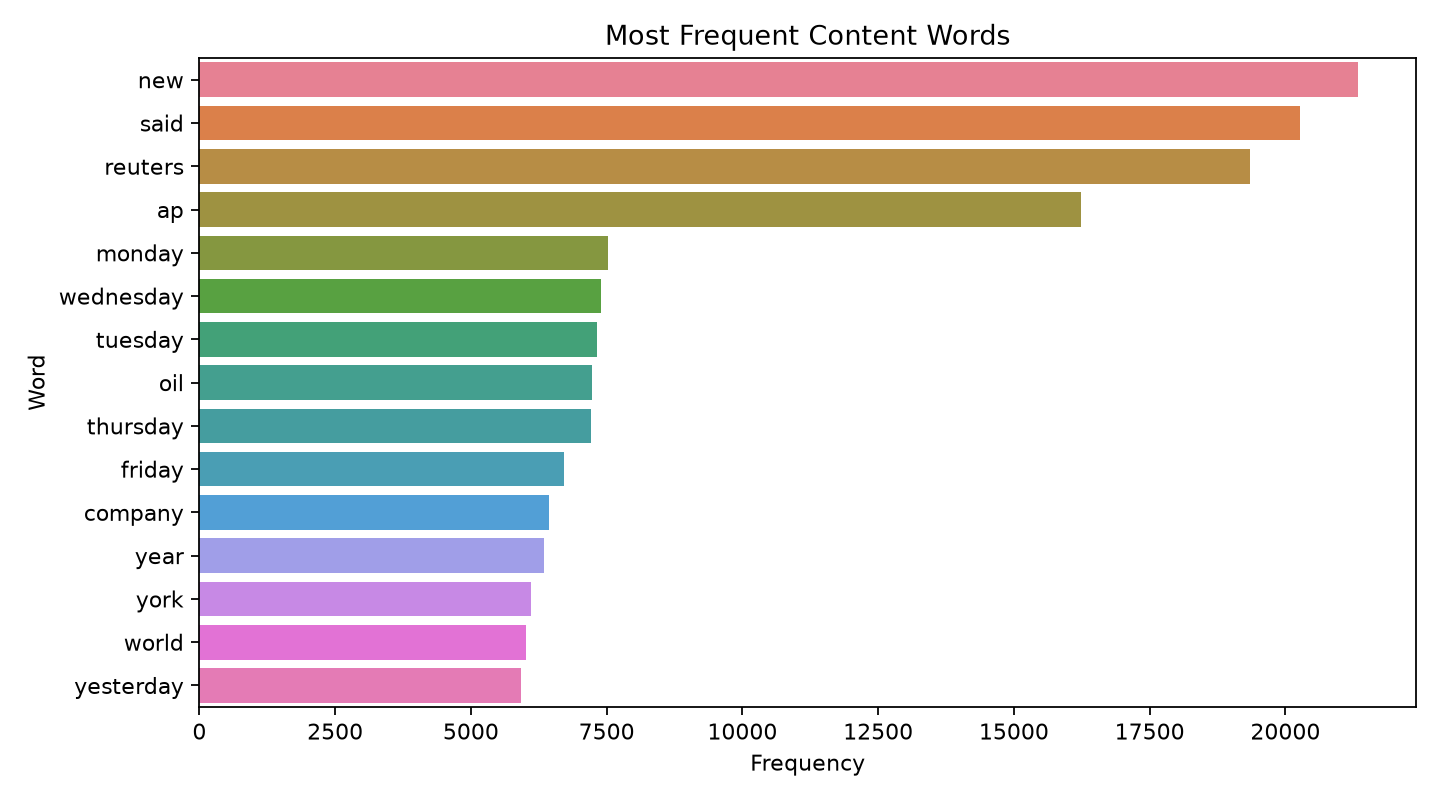

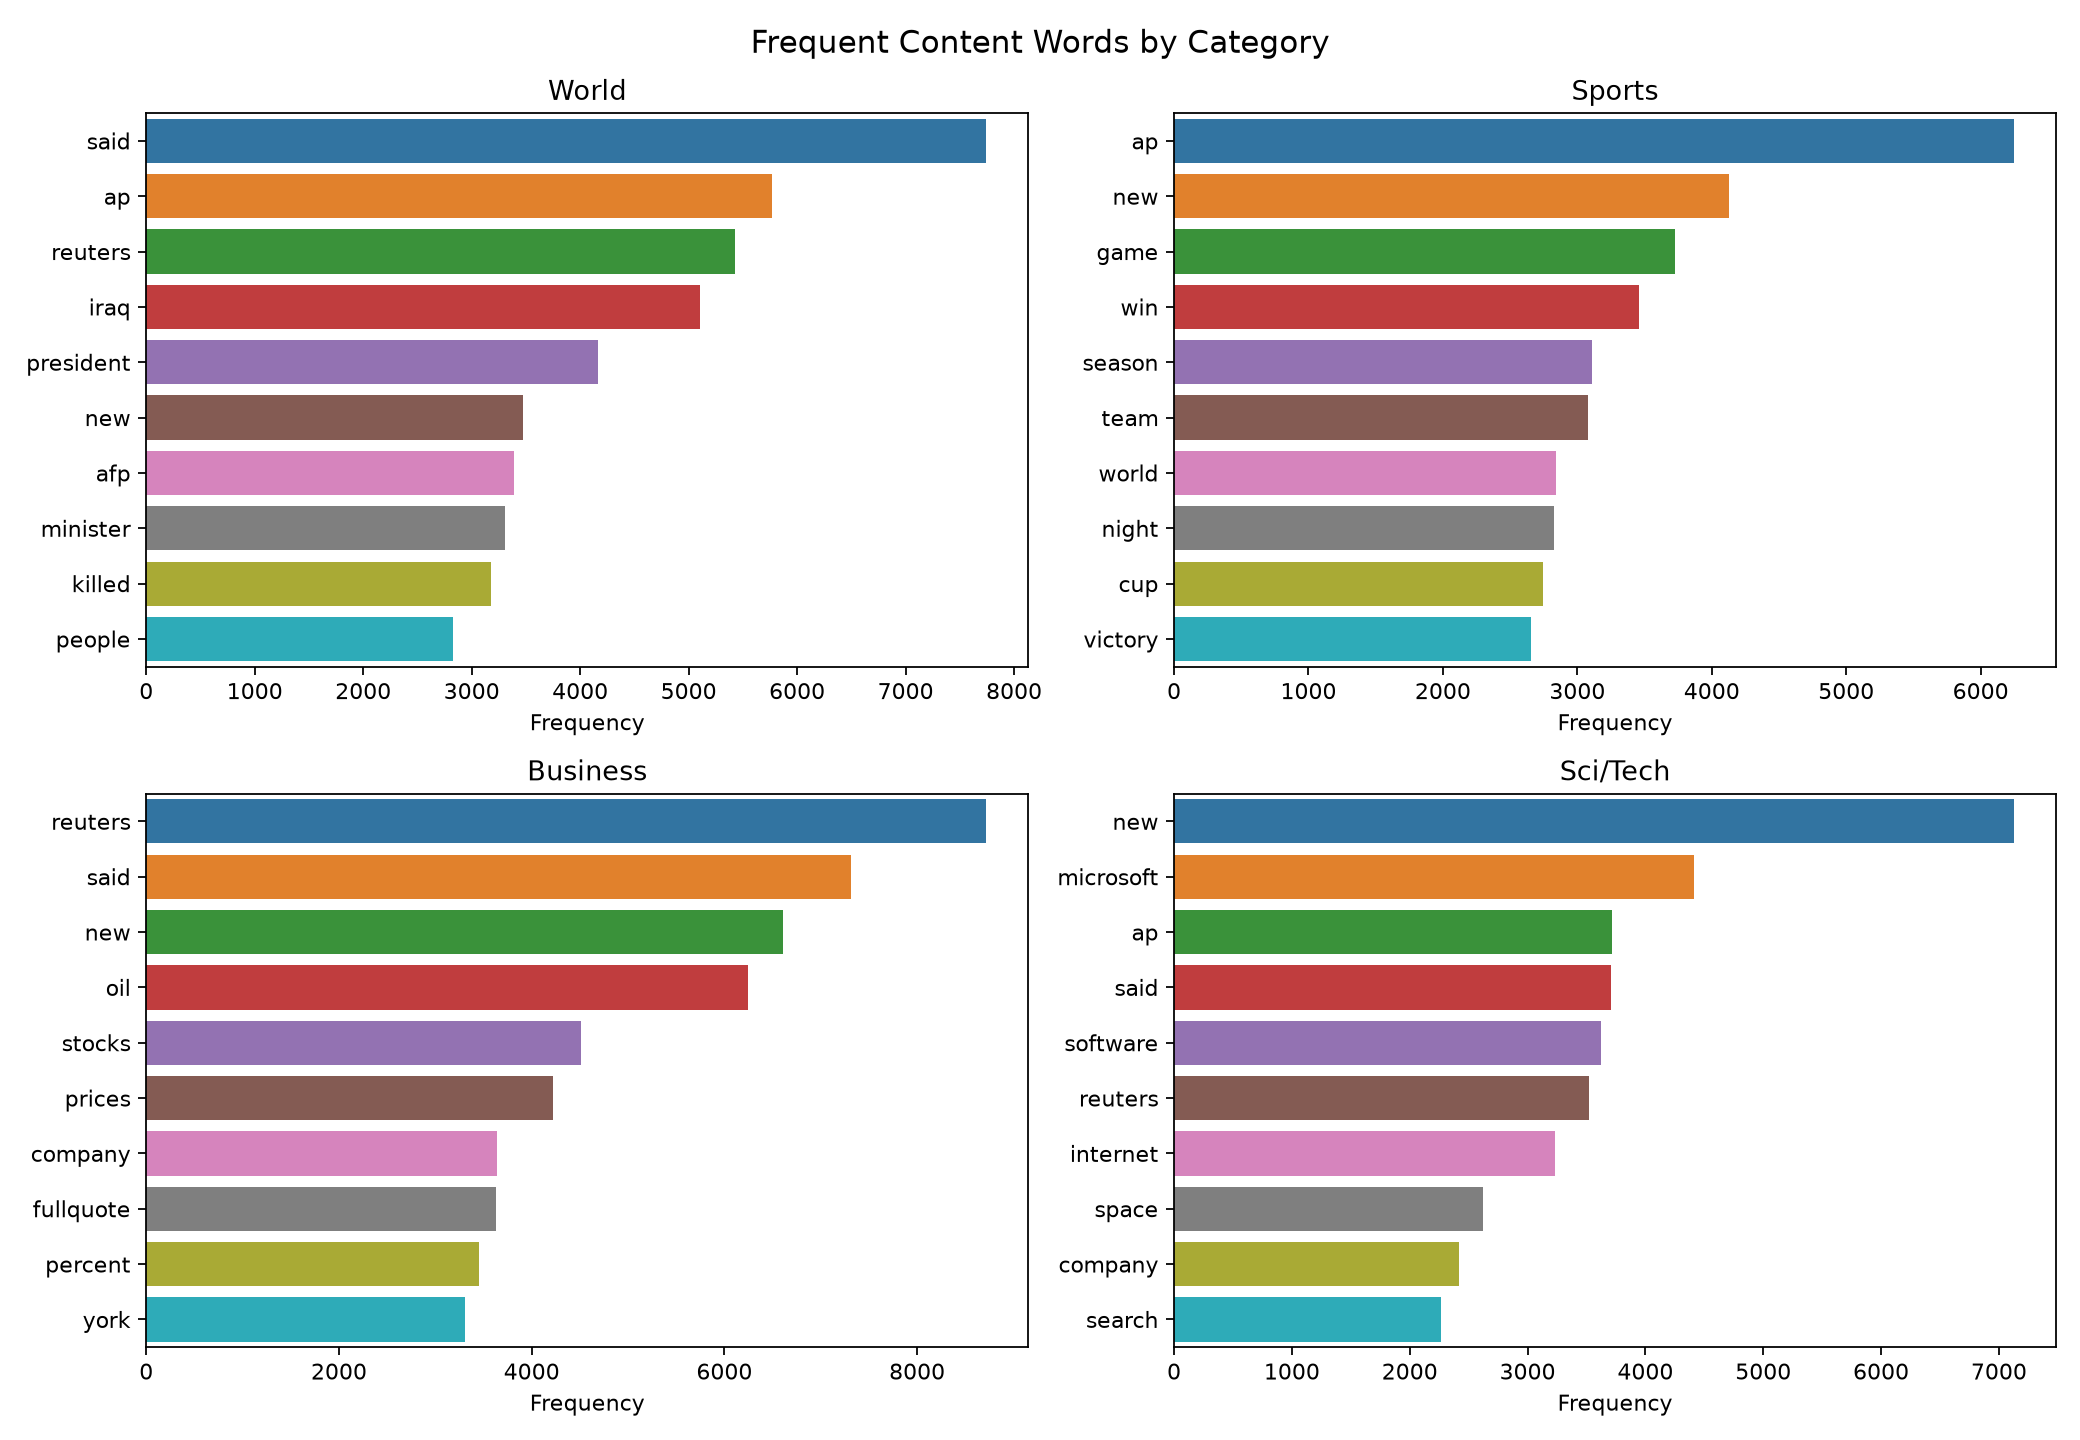

,label_name,text,word_count,token_count
0,Business,US house sales fall in July Sales of non-new h...,21,27
1,Business,"DJ to acquire MarketWatch Dow Jones & Co., pub...",35,47
2,Business,Dollar hits new low on Snow speech The United ...,45,52
3,Sci/Tech,Intuit Posts 1Q Loss; Revenue Up 11 Pct. (AP) ...,33,46
4,Sci/Tech,Q A: Red Hat exec talks of challenges to open-...,27,38
5,Sci/Tech,Women 'better at holding drink' Women are bett...,17,25
6,Sports,Benitez pleased to have avoided Italian team i...,32,41
7,Sports,Gallacher Scores First European Tour Win Scotl...,33,45
8,Sports,Source: Stanford Fires Coach Teevens (AP) AP -...,30,43
9,World,AdWatch: Kerry Accuses Bush on Iraq Money (AP)...,25,34


In [6]:
print('Approximate unique word forms:', summary['unique_words'])
display(pd.DataFrame(summary['top_content_words'], columns=['Word', 'Frequency']))
display(Image(filename=str(FIGURE_DIR / 'top_words.png')))
display(Image(filename=str(FIGURE_DIR / 'top_words_by_class.png')))
display(pd.read_csv(METRICS_DIR / 'eda_class_samples.csv'))

## EDA conclusion

AG News contains 120,000 training articles and 7,600 official test articles.
The original training set is perfectly balanced, with 30,000 articles in each
of the four classes. Therefore, class imbalance is not expected to bias the
classifier. No missing text was found. The training set contained 137 duplicate
texts, which were removed before the train-validation split. Thirteen exact
texts also appeared in both the original training and test sets.

The articles are generally short, averaging 37.68 words and 51.54 DistilBERT
tokens. The 95th percentile is 78 tokens and the 99th percentile is 116 tokens.
Therefore, `max_length=128` covers 99.441% of the training examples while
keeping training efficient. Only 671 unusually long examples require
truncation.

Frequent words include source names such as Reuters and AP, weekdays, and
topic-related words such as oil, company, president, and Iraq. Category-specific
vocabulary can help classification, although some words overlap between
categories, especially Business and Sci/Tech.